In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Read the CSV file (adjust the path as needed)
# Replace 'your_file.csv' with the actual path to your CSV file
df = pd.read_csv('/content/camera_grain_analysis_20250801_11351427.csv')
df.head()

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,label,area,centroid_x,centroid_y,major_axis_length,minor_axis_length,orientation,perimeter,max_intensity,mean_intensity,min_intensity
0,1,0.388688,0.975879,0.246774,0.987720,0.510909,1.359426,2.898045,0.0,0.0,1.797693e+308
1,69,0.232932,3.070411,0.125334,1.107859,0.284151,-1.569013,2.811536,0.0,0.0,1.797693e+308
2,76,1.514061,4.772689,0.549740,1.968244,1.050101,1.087328,6.315142,0.0,0.0,1.797693e+308
3,48,0.669330,6.652472,0.295300,1.342340,0.694396,1.360722,4.065914,0.0,0.0,1.797693e+308
4,70,0.544444,7.593916,0.509243,1.076215,0.764791,-0.116746,4.325440,0.0,0.0,1.797693e+308


In [ ]:

# Calculate sample statistics
clean_data = df['major_axis_length'].dropna()
sample_mean = df['major_axis_length'].mean()
sample_std = df['major_axis_length'].std()

# Calculate empirical D16, D50, D84
empirical_D16 = np.percentile(df['major_axis_length'], 16)
empirical_D50 = np.percentile(df['major_axis_length'], 50)
empirical_D84 = np.percentile(df['major_axis_length'], 84)

# Calculate theoretical D16, D50, D84 from fitted normal distribution
theoretical_D16 = norm.ppf(0.16, loc=sample_mean, scale=sample_std)
theoretical_D50 = norm.ppf(0.50, loc=sample_mean, scale=sample_std)  # Same as mean for normal
theoretical_D84 = norm.ppf(0.84, loc=sample_mean, scale=sample_std)

print("Comparison of Percentiles:")
print("="*50)
print(f"{'Percentile':<12} {'Empirical':<10} {'Normal Fit':<10} {'Difference':<10}")
print("-"*50)
print(f"{'D16':<12} {empirical_D16:<10.3f} {theoretical_D16:<10.3f} {abs(empirical_D16-theoretical_D16):<10.3f}")
print(f"{'D50':<12} {empirical_D50:<10.3f} {theoretical_D50:<10.3f} {abs(empirical_D50-theoretical_D50):<10.3f}")
print(f"{'D84':<12} {empirical_D84:<10.3f} {theoretical_D84:<10.3f} {abs(empirical_D84-theoretical_D84):<10.3f}")

Comparison of Percentiles:
Percentile   Empirical  Normal Fit Difference
--------------------------------------------------
D16          nan        0.979      nan       
D50          nan        1.639      nan       
D84          nan        2.298      nan       


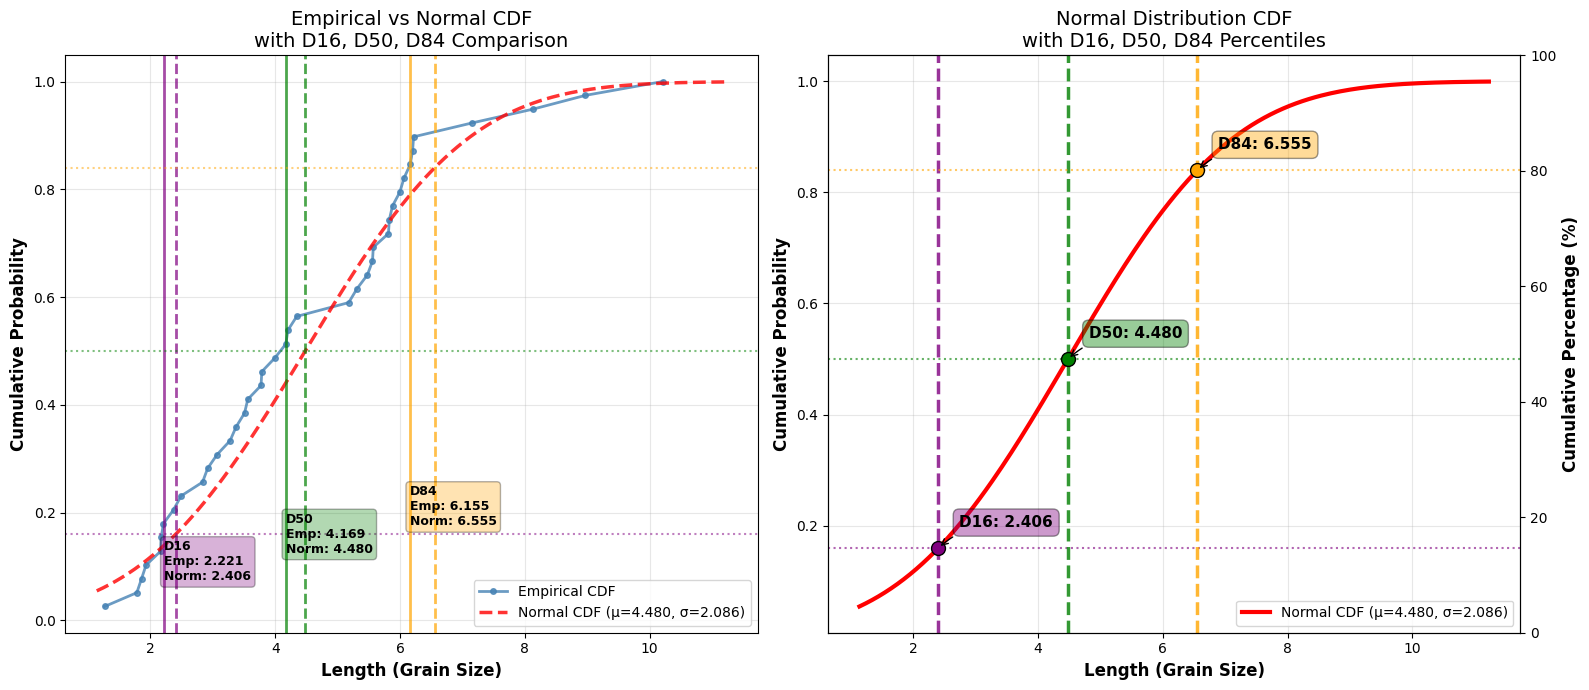

In [ ]:
# Create comprehensive comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Empirical vs Normal CDF with D16, D50, D84
# Empirical CDF
sorted_data = np.sort(df['Length'])
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax1.plot(sorted_data, empirical_cdf, 'o-', linewidth=2, markersize=4,
         color='steelblue', label='Empirical CDF', alpha=0.8)

# Normal distribution CDF
x_range = np.linspace(df['Length'].min() * 0.9, df['Length'].max() * 1.1, 200)
normal_cdf = norm.cdf(x_range, loc=sample_mean, scale=sample_std)
ax1.plot(x_range, normal_cdf, '--', linewidth=2.5, color='red',
         label=f'Normal CDF (μ={sample_mean:.3f}, σ={sample_std:.3f})', alpha=0.8)

# Add D16, D50, D84 lines for both distributions
percentiles = [16, 50, 84]
colors = ['purple', 'green', 'orange']
labels = ['D16', 'D50', 'D84']

for p, color, label in zip(percentiles, colors, labels):
    emp_val = np.percentile(df['Length'], p)
    norm_val = norm.ppf(p/100, loc=sample_mean, scale=sample_std)

    # Empirical percentile line
    ax1.axvline(emp_val, color=color, linestyle='-', linewidth=2, alpha=0.7)
    ax1.axhline(p/100, color=color, linestyle=':', alpha=0.5)

    # Normal percentile line
    ax1.axvline(norm_val, color=color, linestyle='--', linewidth=2, alpha=0.7)

    # Labels
    ax1.text(emp_val, 0.05 + (p/100)*0.15, f'{label}\nEmp: {emp_val:.3f}\nNorm: {norm_val:.3f}',
             rotation=0, fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax1.set_xlabel('Length (Grain Size)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax1.set_title('Empirical vs Normal CDF\nwith D16, D50, D84 Comparison', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# Plot 2: Focus on Normal Distribution CDF only
ax2.plot(x_range, normal_cdf, linewidth=3, color='red',
         label=f'Normal CDF (μ={sample_mean:.3f}, σ={sample_std:.3f})')

# Add D16, D50, D84 for normal distribution
for p, color, label in zip([16, 50, 84], ['purple', 'green', 'orange'], ['D16', 'D50', 'D84']):
    norm_val = norm.ppf(p/100, loc=sample_mean, scale=sample_std)

    # Vertical line at percentile value
    ax2.axvline(norm_val, color=color, linestyle='--', linewidth=2.5, alpha=0.8)
    # Horizontal line at percentile probability
    ax2.axhline(p/100, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    # Point at intersection
    ax2.plot(norm_val, p/100, 'o', color=color, markersize=10,
             markeredgecolor='black', markeredgewidth=1)

    # Annotation
    ax2.annotate(f'{label}: {norm_val:.3f}',
                xy=(norm_val, p/100), xytext=(15, 15),
                textcoords='offset points', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.4),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

ax2.set_xlabel('Length (Grain Size)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Normal Distribution CDF\nwith D16, D50, D84 Percentiles', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')

# Add secondary y-axis with percentages
ax2_y = ax2.twinx()
ax2_y.set_ylim(0, 100)
ax2_y.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

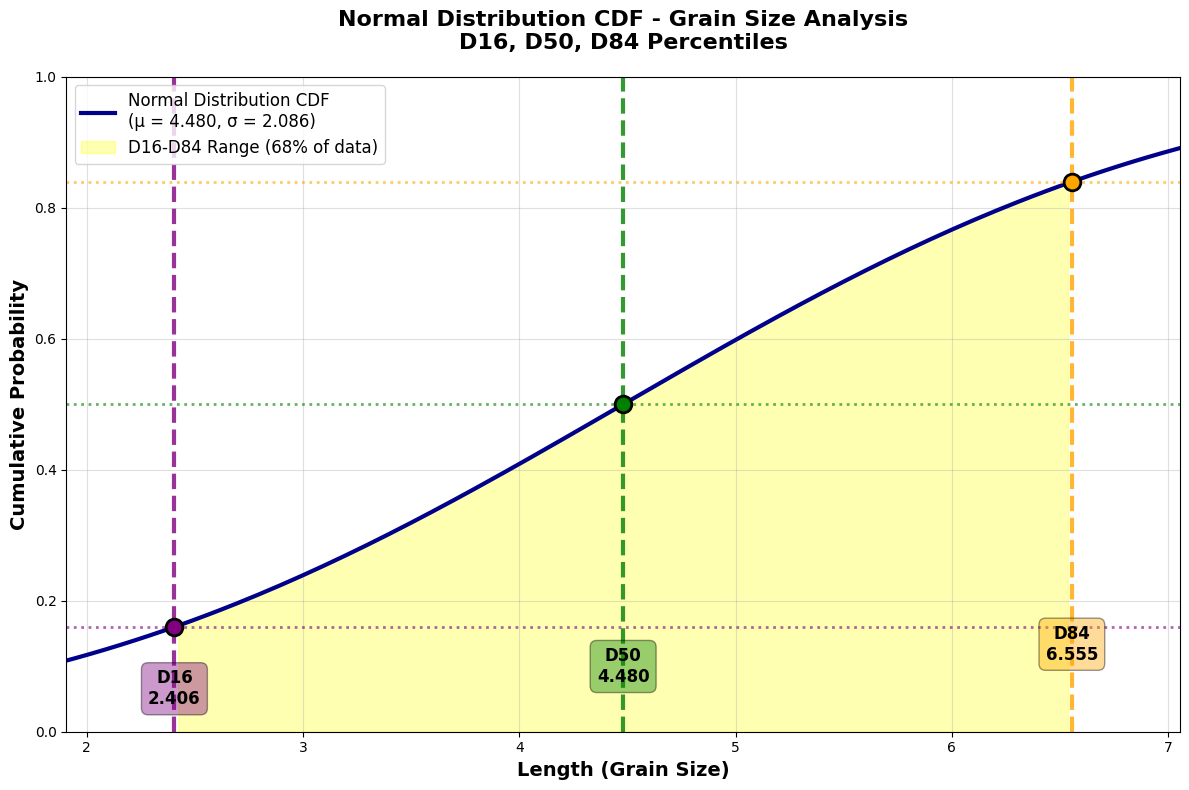

In [ ]:
# Create a focused plot showing just the normal distribution
fig, ax = plt.subplots(figsize=(12, 8))

# Normal CDF
x_fine = np.linspace(sample_mean - 4*sample_std, sample_mean + 4*sample_std, 500)
normal_cdf_fine = norm.cdf(x_fine, loc=sample_mean, scale=sample_std)
ax.plot(x_fine, normal_cdf_fine, linewidth=3, color='darkblue',
        label=f'Normal Distribution CDF\n(μ = {sample_mean:.3f}, σ = {sample_std:.3f})')

# Highlight the D16-D84 region
ax.fill_between(x_fine, 0, normal_cdf_fine,
                where=(x_fine >= theoretical_D16) & (x_fine <= theoretical_D84),
                alpha=0.3, color='yellow', label='D16-D84 Range (68% of data)')

# Add percentile markers and lines
percentile_data = [
    (16, theoretical_D16, 'purple', 'D16'),
    (50, theoretical_D50, 'green', 'D50'),
    (84, theoretical_D84, 'orange', 'D84')
]

for p, value, color, label in percentile_data:
    # Vertical line
    ax.axvline(value, color=color, linestyle='--', linewidth=3, alpha=0.8)
    # Horizontal line
    ax.axhline(p/100, color=color, linestyle=':', linewidth=2, alpha=0.6)
    # Intersection point
    ax.plot(value, p/100, 'o', color=color, markersize=12,
            markeredgecolor='black', markeredgewidth=2, zorder=10)

    # Value label
    ax.text(value, 0.02 + (p/100)*0.1, f'{label}\n{value:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.4))

# Formatting
ax.set_xlabel('Length (Grain Size)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=14, fontweight='bold')
ax.set_title('Normal Distribution CDF - Grain Size Analysis\nD16, D50, D84 Percentiles',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=12)

# Set reasonable axis limits
ax.set_xlim(theoretical_D16 - 0.5, theoretical_D84 + 0.5)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Print detailed analysis
print("\nNormal Distribution Analysis:")
print("="*50)
print(f"Fitted Normal Distribution Parameters:")
print(f"Mean (μ): {sample_mean:.3f}")
print(f"Standard Deviation (σ): {sample_std:.3f}")
print(f"\nTheoretical Percentiles from Normal Distribution:")
print(f"D16 (μ - 1σ): {theoretical_D16:.3f}")
print(f"D50 (μ): {theoretical_D50:.3f}")
print(f"D84 (μ + 1σ): {theoretical_D84:.3f}")
print(f"\nNormal Distribution Sorting Parameters:")
print(f"Theoretical sorting coefficient (D84/D16): {theoretical_D84/theoretical_D16:.3f}")
print(f"Geometric mean: {np.sqrt(theoretical_D16*theoretical_D84):.3f}")

# Goodness of fit test
from scipy.stats import kstest
ks_stat, ks_p = kstest(df['Length'], 'norm', args=(sample_mean, sample_std))
print(f"\nGoodness of Fit (Kolmogorov-Smirnov Test):")
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {ks_p:.4f}")
if ks_p > 0.05:
    print("Data appears to follow normal distribution (p > 0.05)")
else:
    print("Data may not follow normal distribution (p ≤ 0.05)")


Normal Distribution Analysis:
Fitted Normal Distribution Parameters:
Mean (μ): 4.480
Standard Deviation (σ): 2.086

Theoretical Percentiles from Normal Distribution:
D16 (μ - 1σ): 2.406
D50 (μ): 4.480
D84 (μ + 1σ): 6.555

Normal Distribution Sorting Parameters:
Theoretical sorting coefficient (D84/D16): 2.725
Geometric mean: 3.971

Goodness of Fit (Kolmogorov-Smirnov Test):
KS Statistic: 0.1000
P-value: 0.7936
Data appears to follow normal distribution (p > 0.05)


In [ ]:
df1 = pd.read_csv('/content/grain_analysis_20250806_152433.csv')
df1.head()

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,label,area,centroid_x,centroid_y,major_axis_length,minor_axis_length,orientation,perimeter,max_intensity,mean_intensity,min_intensity
0,32,21.356652,2.692197,2.052883,7.328725,4.291717,-1.003100,27.624434,0.0,0.0,1.797693e+308
1,1,40.875610,11.138246,3.192527,8.068907,6.645635,0.770475,29.426027,0.0,0.0,1.797693e+308
2,29,1.354617,14.628716,0.324445,2.378271,0.799833,-1.540026,6.806020,0.0,0.0,1.797693e+308
3,30,2.281813,15.661267,1.408075,3.351214,0.922535,-0.504151,9.408322,0.0,0.0,1.797693e+308
4,2,16.370057,18.095224,2.412381,5.444320,3.978271,-0.002239,20.151157,0.0,0.0,1.797693e+308


In [ ]:
clean_data = df1['major_axis_length'].dropna()

In [ ]:
print(f"Data cleaning summary for Major Axis Length:")
print(f"Original data points: {len(df1)}")
print(f"After removing NaN: {len(clean_data)}")
print(f"Removed {len(df1) - len(clean_data)} NaN values")
print("-" * 50)

Data cleaning summary for Major Axis Length:
Original data points: 57
After removing NaN: 52
Removed 5 NaN values
--------------------------------------------------


In [ ]:
# Calculate sample statistics
sample_mean = clean_data.mean()
sample_std = clean_data.std()

# Calculate empirical D16, D50, D84
empirical_D16 = np.percentile(clean_data, 16)
empirical_D50 = np.percentile(clean_data, 50)
empirical_D84 = np.percentile(clean_data, 84)

# Calculate theoretical D16, D50, D84 from fitted normal distribution
theoretical_D16 = norm.ppf(0.16, loc=sample_mean, scale=sample_std)
theoretical_D50 = norm.ppf(0.50, loc=sample_mean, scale=sample_std)  # Same as mean for normal
theoretical_D84 = norm.ppf(0.84, loc=sample_mean, scale=sample_std)

print("Comparison of Percentiles:")
print("="*50)
print(f"{'Percentile':<12} {'Empirical':<10} {'Normal Fit':<10} {'Difference':<10}")
print("-"*50)
print(f"{'D16':<12} {empirical_D16:<10.3f} {theoretical_D16:<10.3f} {abs(empirical_D16-theoretical_D16):<10.3f}")
print(f"{'D50':<12} {empirical_D50:<10.3f} {theoretical_D50:<10.3f} {abs(empirical_D50-theoretical_D50):<10.3f}")
print(f"{'D84':<12} {empirical_D84:<10.3f} {theoretical_D84:<10.3f} {abs(empirical_D84-theoretical_D84):<10.3f}")

Comparison of Percentiles:
Percentile   Empirical  Normal Fit Difference
--------------------------------------------------
D16          2.442      2.558      0.117     
D50          4.293      4.738      0.445     
D84          7.004      6.918      0.086     


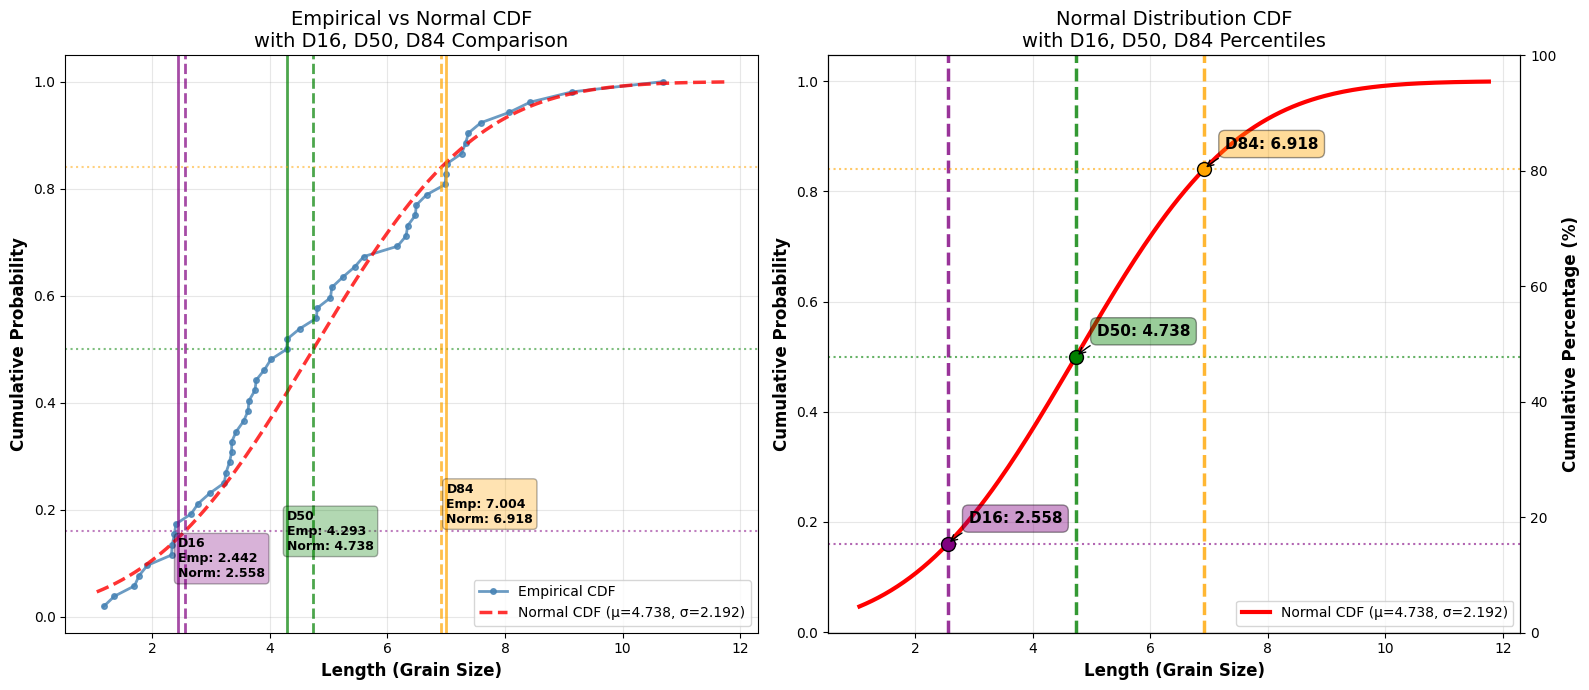

In [ ]:
# Create comprehensive comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Empirical vs Normal CDF with D16, D50, D84
# Empirical CDF
sorted_data = np.sort(clean_data)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
ax1.plot(sorted_data, empirical_cdf, 'o-', linewidth=2, markersize=4,
         color='steelblue', label='Empirical CDF', alpha=0.8)

# Normal distribution CDF
x_range = np.linspace(clean_data.min() * 0.9, clean_data.max() * 1.1, 200)
normal_cdf = norm.cdf(x_range, loc=sample_mean, scale=sample_std)
ax1.plot(x_range, normal_cdf, '--', linewidth=2.5, color='red',
         label=f'Normal CDF (μ={sample_mean:.3f}, σ={sample_std:.3f})', alpha=0.8)

# Add D16, D50, D84 lines for both distributions
percentiles = [16, 50, 84]
colors = ['purple', 'green', 'orange']
labels = ['D16', 'D50', 'D84']

for p, color, label in zip(percentiles, colors, labels):
    emp_val = np.percentile(clean_data, p)
    norm_val = norm.ppf(p/100, loc=sample_mean, scale=sample_std)

    # Empirical percentile line
    ax1.axvline(emp_val, color=color, linestyle='-', linewidth=2, alpha=0.7)
    ax1.axhline(p/100, color=color, linestyle=':', alpha=0.5)

    # Normal percentile line
    ax1.axvline(norm_val, color=color, linestyle='--', linewidth=2, alpha=0.7)

    # Labels
    ax1.text(emp_val, 0.05 + (p/100)*0.15, f'{label}\nEmp: {emp_val:.3f}\nNorm: {norm_val:.3f}',
             rotation=0, fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax1.set_xlabel('Length (Grain Size)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax1.set_title('Empirical vs Normal CDF\nwith D16, D50, D84 Comparison', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# Plot 2: Focus on Normal Distribution CDF only
ax2.plot(x_range, normal_cdf, linewidth=3, color='red',
         label=f'Normal CDF (μ={sample_mean:.3f}, σ={sample_std:.3f})')

# Add D16, D50, D84 for normal distribution
for p, color, label in zip([16, 50, 84], ['purple', 'green', 'orange'], ['D16', 'D50', 'D84']):
    norm_val = norm.ppf(p/100, loc=sample_mean, scale=sample_std)

    # Vertical line at percentile value
    ax2.axvline(norm_val, color=color, linestyle='--', linewidth=2.5, alpha=0.8)
    # Horizontal line at percentile probability
    ax2.axhline(p/100, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    # Point at intersection
    ax2.plot(norm_val, p/100, 'o', color=color, markersize=10,
             markeredgecolor='black', markeredgewidth=1)

    # Annotation
    ax2.annotate(f'{label}: {norm_val:.3f}',
                xy=(norm_val, p/100), xytext=(15, 15),
                textcoords='offset points', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.4),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

ax2.set_xlabel('Length (Grain Size)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Normal Distribution CDF\nwith D16, D50, D84 Percentiles', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right')

# Add secondary y-axis with percentages
ax2_y = ax2.twinx()
ax2_y.set_ylim(0, 100)
ax2_y.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

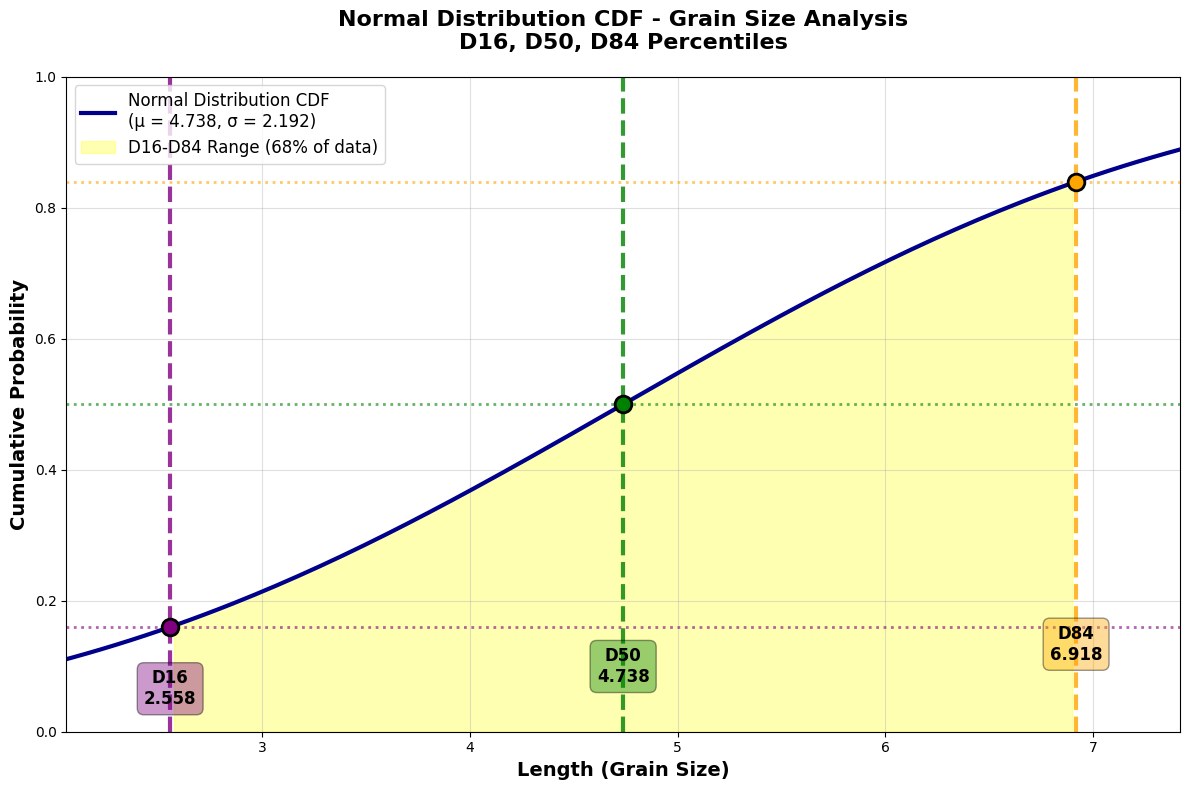

In [ ]:
# Create a focused plot showing just the normal distribution
fig, ax = plt.subplots(figsize=(12, 8))

# Normal CDF
x_fine = np.linspace(sample_mean - 4*sample_std, sample_mean + 4*sample_std, 500)
normal_cdf_fine = norm.cdf(x_fine, loc=sample_mean, scale=sample_std)
ax.plot(x_fine, normal_cdf_fine, linewidth=3, color='darkblue',
        label=f'Normal Distribution CDF\n(μ = {sample_mean:.3f}, σ = {sample_std:.3f})')

# Highlight the D16-D84 region
ax.fill_between(x_fine, 0, normal_cdf_fine,
                where=(x_fine >= theoretical_D16) & (x_fine <= theoretical_D84),
                alpha=0.3, color='yellow', label='D16-D84 Range (68% of data)')

# Add percentile markers and lines
percentile_data = [
    (16, theoretical_D16, 'purple', 'D16'),
    (50, theoretical_D50, 'green', 'D50'),
    (84, theoretical_D84, 'orange', 'D84')
]

for p, value, color, label in percentile_data:
    # Vertical line
    ax.axvline(value, color=color, linestyle='--', linewidth=3, alpha=0.8)
    # Horizontal line
    ax.axhline(p/100, color=color, linestyle=':', linewidth=2, alpha=0.6)
    # Intersection point
    ax.plot(value, p/100, 'o', color=color, markersize=12,
            markeredgecolor='black', markeredgewidth=2, zorder=10)

    # Value label
    ax.text(value, 0.02 + (p/100)*0.1, f'{label}\n{value:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.4))

# Formatting
ax.set_xlabel('Length (Grain Size)', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=14, fontweight='bold')
ax.set_title('Normal Distribution CDF - Grain Size Analysis\nD16, D50, D84 Percentiles',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=12)

# Set reasonable axis limits
ax.set_xlim(theoretical_D16 - 0.5, theoretical_D84 + 0.5)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Normal Distribution Parameters:
Length Dataset:
  μ = 4.480, σ = 2.086
  D16: 2.406
  D50: 4.480
  D84: 6.555

Major Axis Dataset:
  μ = 4.738, σ = 2.192
  D16: 2.558
  D50: 4.738
  D84: 6.918


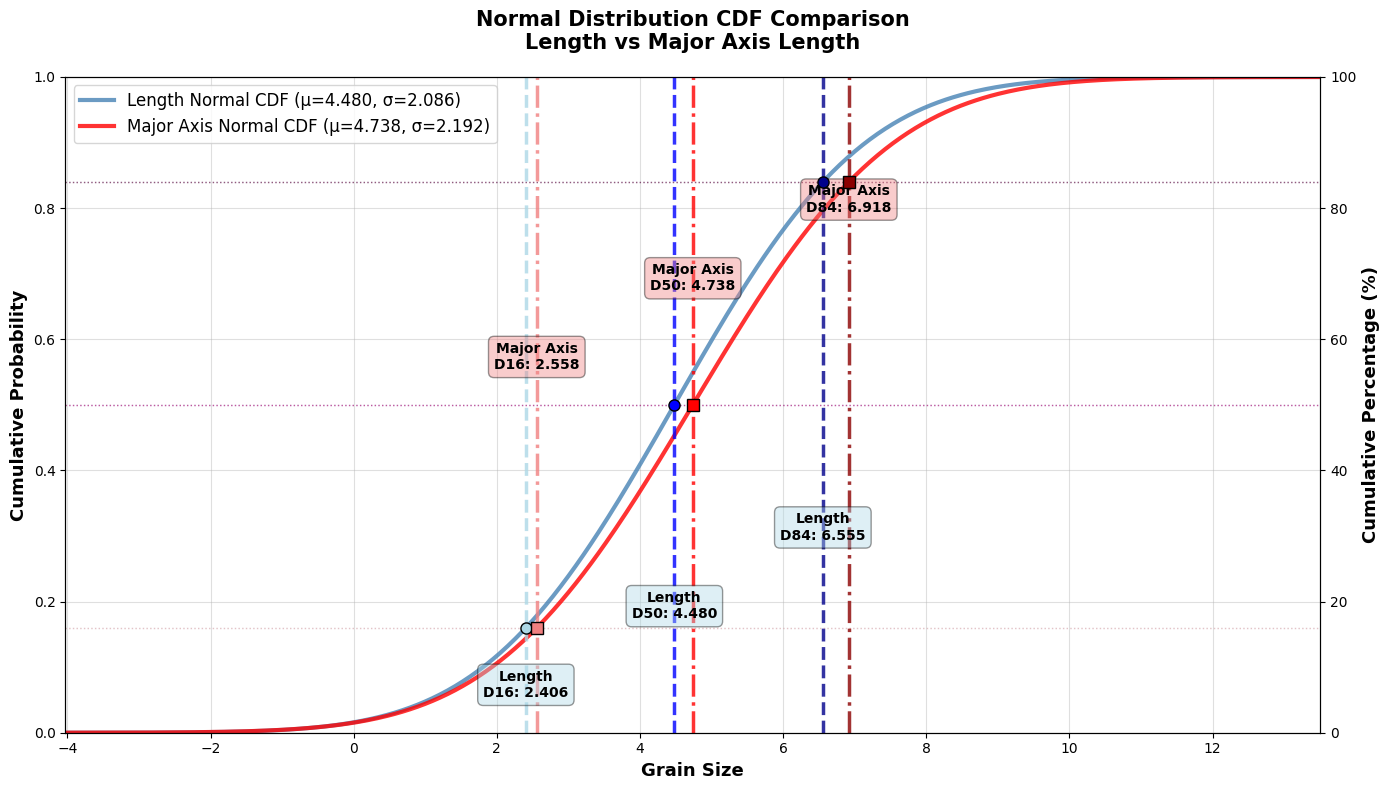

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Clean both datasets
clean_length = df['Length'].dropna()
clean_major_axis = df1['major_axis_length'].dropna()

# Calculate sample statistics for fitting normal distributions
mean_length, std_length = clean_length.mean(), clean_length.std()
mean_major, std_major = clean_major_axis.mean(), clean_major_axis.std()

# Calculate theoretical D16, D50, D84 from fitted normal distributions
# Length dataset
theoretical_D16_length = norm.ppf(0.16, loc=mean_length, scale=std_length)
theoretical_D50_length = norm.ppf(0.50, loc=mean_length, scale=std_length)
theoretical_D84_length = norm.ppf(0.84, loc=mean_length, scale=std_length)

# Major Axis dataset
theoretical_D16_major = norm.ppf(0.16, loc=mean_major, scale=std_major)
theoretical_D50_major = norm.ppf(0.50, loc=mean_major, scale=std_major)
theoretical_D84_major = norm.ppf(0.84, loc=mean_major, scale=std_major)

print("Normal Distribution Parameters:")
print("="*50)
print(f"Length Dataset:")
print(f"  μ = {mean_length:.3f}, σ = {std_length:.3f}")
print(f"  D16: {theoretical_D16_length:.3f}")
print(f"  D50: {theoretical_D50_length:.3f}")
print(f"  D84: {theoretical_D84_length:.3f}")
print(f"\nMajor Axis Dataset:")
print(f"  μ = {mean_major:.3f}, σ = {std_major:.3f}")
print(f"  D16: {theoretical_D16_major:.3f}")
print(f"  D50: {theoretical_D50_major:.3f}")
print(f"  D84: {theoretical_D84_major:.3f}")

# Create the comparison plot with only normal CDFs
fig, ax = plt.subplots(figsize=(14, 8))

# Define x-range that covers both distributions
x_min = min(mean_length - 4*std_length, mean_major - 4*std_major)
x_max = max(mean_length + 4*std_length, mean_major + 4*std_major)
x_range = np.linspace(x_min, x_max, 500)

# Calculate normal CDFs
normal_cdf_length = norm.cdf(x_range, loc=mean_length, scale=std_length)
normal_cdf_major = norm.cdf(x_range, loc=mean_major, scale=std_major)

# Plot normal distribution CDFs
ax.plot(x_range, normal_cdf_length, linewidth=3, color='steelblue',
        label=f'Length Normal CDF (μ={mean_length:.3f}, σ={std_length:.3f})', alpha=0.8)
ax.plot(x_range, normal_cdf_major, linewidth=3, color='red',
        label=f'Major Axis Normal CDF (μ={mean_major:.3f}, σ={std_major:.3f})', alpha=0.8)

# Add D16, D50, D84 lines for Length dataset
percentiles = [16, 50, 84]
colors_length = ['lightblue', 'blue', 'darkblue']
values_length = [theoretical_D16_length, theoretical_D50_length, theoretical_D84_length]
labels_percentiles = ['D16', 'D50', 'D84']

for p, color, value, label in zip(percentiles, colors_length, values_length, labels_percentiles):
    ax.axvline(value, color=color, linestyle='--', linewidth=2.5, alpha=0.8)
    ax.axhline(p/100, color=color, linestyle=':', linewidth=1, alpha=0.4)
    # Add point at intersection
    ax.plot(value, p/100, 'o', color=color, markersize=8,
            markeredgecolor='black', markeredgewidth=1, zorder=10)

# Add D16, D50, D84 lines for Major Axis dataset
colors_major = ['lightcoral', 'red', 'darkred']
values_major = [theoretical_D16_major, theoretical_D50_major, theoretical_D84_major]

for p, color, value, label in zip(percentiles, colors_major, values_major, labels_percentiles):
    ax.axvline(value, color=color, linestyle='-.', linewidth=2.5, alpha=0.8)
    ax.axhline(p/100, color=color, linestyle=':', linewidth=1, alpha=0.4)
    # Add point at intersection
    ax.plot(value, p/100, 's', color=color, markersize=8,
            markeredgecolor='black', markeredgewidth=1, zorder=10)

# Add text annotations for percentiles
# Length dataset annotations
for i, (p, value, label) in enumerate(zip([16, 50, 84], values_length, ['D16', 'D50', 'D84'])):
    ax.text(value, 0.05 + i*0.12, f'Length\n{label}: {value:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.4))

# Major Axis dataset annotations
for i, (p, value, label) in enumerate(zip([16, 50, 84], values_major, ['D16', 'D50', 'D84'])):
    ax.text(value, 0.55 + i*0.12, f'Major Axis\n{label}: {value:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightcoral', alpha=0.4))

# Formatting
ax.set_xlabel('Grain Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
ax.set_title('Normal Distribution CDF Comparison\nLength vs Major Axis Length',
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=12)

# Set axis limits
ax.set_xlim(x_min, x_max)
ax.set_ylim(0, 1)

# Add secondary y-axis with percentages
ax2_y = ax.twinx()
ax2_y.set_ylim(0, 100)
ax2_y.set_ylabel('Cumulative Percentage (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

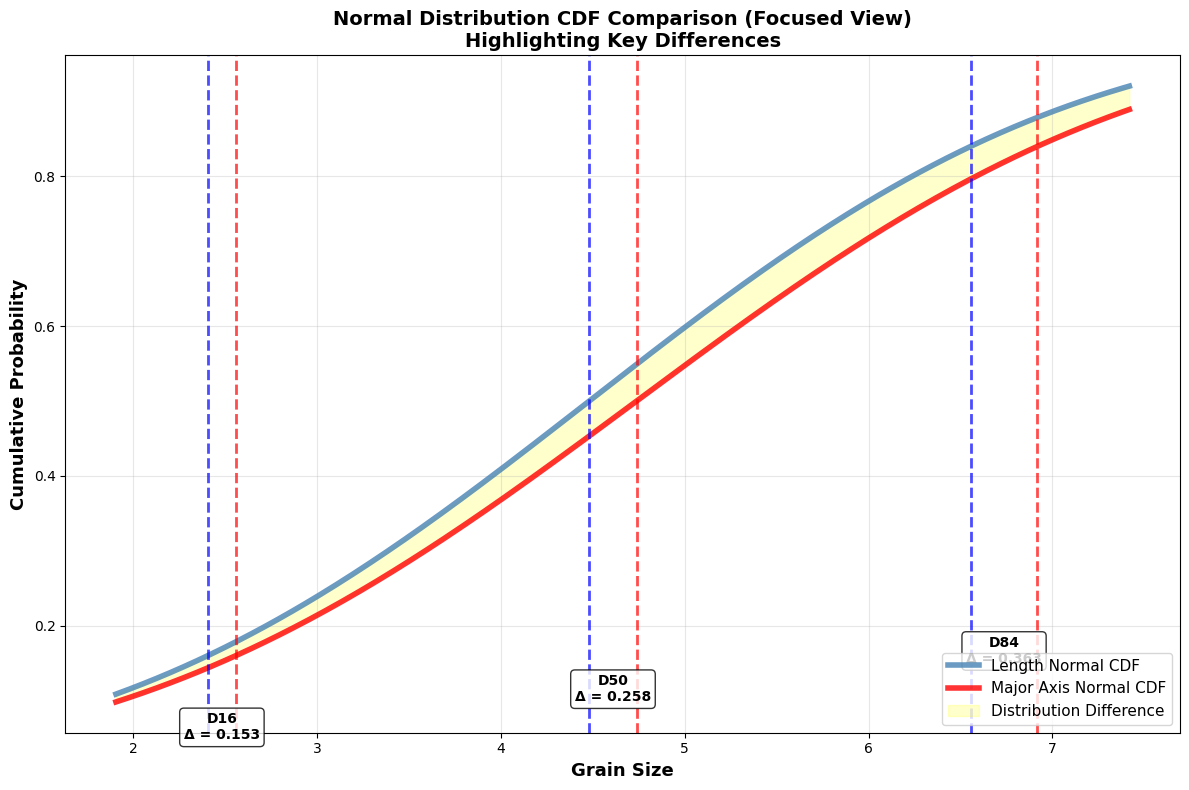

In [ ]:
# Create a focused comparison plot
fig, ax = plt.subplots(figsize=(12, 8))

# Focus on the range where both distributions overlap significantly
focus_min = min(theoretical_D16_length, theoretical_D16_major) - 0.5
focus_max = max(theoretical_D84_length, theoretical_D84_major) + 0.5
x_focus = np.linspace(focus_min, focus_max, 300)

# Calculate CDFs for focused range
cdf_length_focus = norm.cdf(x_focus, loc=mean_length, scale=std_length)
cdf_major_focus = norm.cdf(x_focus, loc=mean_major, scale=std_major)

# Plot focused CDFs
ax.plot(x_focus, cdf_length_focus, linewidth=4, color='steelblue',
        label=f'Length Normal CDF', alpha=0.8)
ax.plot(x_focus, cdf_major_focus, linewidth=4, color='red',
        label=f'Major Axis Normal CDF', alpha=0.8)

# Highlight the area between curves to show difference
ax.fill_between(x_focus, cdf_length_focus, cdf_major_focus,
                alpha=0.2, color='yellow', label='Distribution Difference')

# Add key percentile lines with cleaner annotation
percentile_data = [
    (16, theoretical_D16_length, theoretical_D16_major, 'D16'),
    (50, theoretical_D50_length, theoretical_D50_major, 'D50'),
    (84, theoretical_D84_length, theoretical_D84_major, 'D84')
]

for p, val_length, val_major, label in percentile_data:
    # Length percentile
    ax.axvline(val_length, color='blue', linestyle='--', linewidth=2, alpha=0.7)
    # Major Axis percentile
    ax.axvline(val_major, color='red', linestyle='--', linewidth=2, alpha=0.7)

    # Add comparison text
    diff = abs(val_length - val_major)
    mid_point = (val_length + val_major) / 2
    ax.text(mid_point, 0.02 + (p/100)*0.15,
            f'{label}\nΔ = {diff:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Grain Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=13, fontweight='bold')
ax.set_title('Normal Distribution CDF Comparison (Focused View)\nHighlighting Key Differences',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Read the CSV files from both methods
# Replace with your actual file paths
df_camera = pd.read_csv('/content/camera_grain_analysis_20250801_11351427.csv')
df_upload = pd.read_csv('/content/grain_analysis_20250807_12285627.csv')

# Clean the data by removing NaN values
camera_major = df_camera['major_axis_length'].dropna()
camera_minor = df_camera['minor_axis_length'].dropna()
upload_major = df_upload['major_axis_length'].dropna()
upload_minor = df_upload['minor_axis_length'].dropna()

print("Data Summary:")
print("="*60)
print(f"Camera Method - Major Axis: {len(camera_major)} grains")
print(f"Camera Method - Minor Axis: {len(camera_minor)} grains")
print(f"Upload Method - Major Axis: {len(upload_major)} grains")
print(f"Upload Method - Minor Axis: {len(upload_minor)} grains")

# Calculate basic statistics for all datasets
datasets = {
    'Camera Major': camera_major,
    'Camera Minor': camera_minor,
    'Upload Major': upload_major,
    'Upload Minor': upload_minor
}

print(f"\nBasic Statistics:")
print("-"*80)
print(f"{'Dataset':<15} {'Count':<8} {'Mean':<10} {'Std':<10} {'D16':<10} {'D50':<10} {'D84':<10}")
print("-"*80)

stats_summary = {}
for name, data in datasets.items():
    if len(data) > 0:
        mean_val = data.mean()
        std_val = data.std()
        d16 = np.percentile(data, 16)
        d50 = np.percentile(data, 50)
        d84 = np.percentile(data, 84)
        stats_summary[name] = {
            'mean': mean_val, 'std': std_val,
            'D16': d16, 'D50': d50, 'D84': d84, 'data': data
        }
        print(f"{name:<15} {len(data):<8} {mean_val:<10.3f} {std_val:<10.3f} {d16:<10.3f} {d50:<10.3f} {d84:<10.3f}")
    else:
        print(f"{name:<15} No valid data")
        stats_summary[name] = None

Data Summary:
Camera Method - Major Axis: 128 grains
Camera Method - Minor Axis: 128 grains
Upload Method - Major Axis: 250 grains
Upload Method - Minor Axis: 250 grains

Basic Statistics:
--------------------------------------------------------------------------------
Dataset         Count    Mean       Std        D16        D50        D84       
--------------------------------------------------------------------------------
Camera Major    128      1.639      0.663      0.938      1.630      2.233     
Camera Minor    128      0.890      0.433      0.476      0.851      1.308     
Upload Major    250      3.217      1.569      1.605      2.945      4.737     
Upload Minor    250      1.813      0.922      0.907      1.692      2.658     


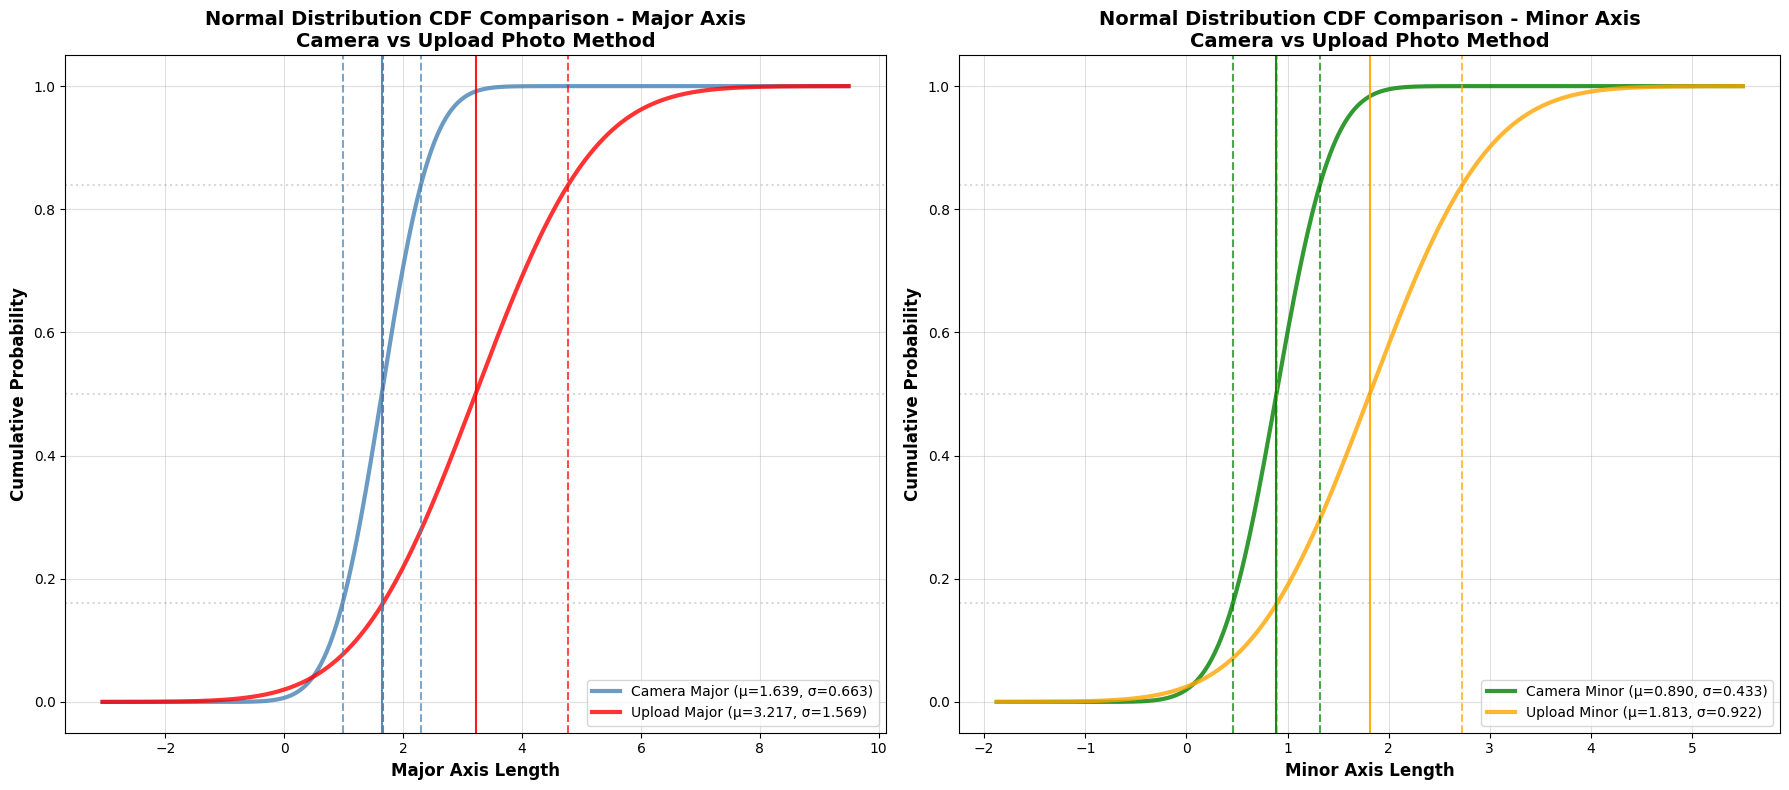

In [ ]:
# Create normal distribution CDF comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Major Axis Normal CDFs
if stats_summary['Camera Major'] and stats_summary['Upload Major']:
    # Get parameters
    camera_major_mean = stats_summary['Camera Major']['mean']
    camera_major_std = stats_summary['Camera Major']['std']
    upload_major_mean = stats_summary['Upload Major']['mean']
    upload_major_std = stats_summary['Upload Major']['std']

    # Create x range for plotting
    x_min = min(camera_major_mean - 4*camera_major_std, upload_major_mean - 4*upload_major_std)
    x_max = max(camera_major_mean + 4*camera_major_std, upload_major_mean + 4*upload_major_std)
    x_major = np.linspace(x_min, x_max, 500)

    # Calculate normal CDFs
    camera_major_cdf = norm.cdf(x_major, loc=camera_major_mean, scale=camera_major_std)
    upload_major_cdf = norm.cdf(x_major, loc=upload_major_mean, scale=upload_major_std)

    # Plot normal CDFs
    ax1.plot(x_major, camera_major_cdf, linewidth=3, color='steelblue',
             label=f'Camera Major (μ={camera_major_mean:.3f}, σ={camera_major_std:.3f})', alpha=0.8)
    ax1.plot(x_major, upload_major_cdf, linewidth=3, color='red',
             label=f'Upload Major (μ={upload_major_mean:.3f}, σ={upload_major_std:.3f})', alpha=0.8)

    # Add theoretical D16, D50, D84 lines
    for p, style, alpha in [(16, '--', 0.7), (50, '-', 0.9), (84, '--', 0.7)]:
        camera_val = norm.ppf(p/100, loc=camera_major_mean, scale=camera_major_std)
        upload_val = norm.ppf(p/100, loc=upload_major_mean, scale=upload_major_std)
        ax1.axvline(camera_val, color='steelblue', linestyle=style, alpha=alpha)
        ax1.axvline(upload_val, color='red', linestyle=style, alpha=alpha)
        ax1.axhline(p/100, color='gray', linestyle=':', alpha=0.3)

ax1.set_xlabel('Major Axis Length', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax1.set_title('Normal Distribution CDF Comparison - Major Axis\nCamera vs Upload Photo Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.4)
ax1.legend(loc='lower right')

# Plot 2: Minor Axis Normal CDFs
if stats_summary['Camera Minor'] and stats_summary['Upload Minor']:
    # Get parameters
    camera_minor_mean = stats_summary['Camera Minor']['mean']
    camera_minor_std = stats_summary['Camera Minor']['std']
    upload_minor_mean = stats_summary['Upload Minor']['mean']
    upload_minor_std = stats_summary['Upload Minor']['std']

    # Create x range for plotting
    x_min = min(camera_minor_mean - 4*camera_minor_std, upload_minor_mean - 4*upload_minor_std)
    x_max = max(camera_minor_mean + 4*camera_minor_std, upload_minor_mean + 4*upload_minor_std)
    x_minor = np.linspace(x_min, x_max, 500)

    # Calculate normal CDFs
    camera_minor_cdf = norm.cdf(x_minor, loc=camera_minor_mean, scale=camera_minor_std)
    upload_minor_cdf = norm.cdf(x_minor, loc=upload_minor_mean, scale=upload_minor_std)

    # Plot normal CDFs
    ax2.plot(x_minor, camera_minor_cdf, linewidth=3, color='green',
             label=f'Camera Minor (μ={camera_minor_mean:.3f}, σ={camera_minor_std:.3f})', alpha=0.8)
    ax2.plot(x_minor, upload_minor_cdf, linewidth=3, color='orange',
             label=f'Upload Minor (μ={upload_minor_mean:.3f}, σ={upload_minor_std:.3f})', alpha=0.8)

    # Add theoretical D16, D50, D84 lines
    for p, style, alpha in [(16, '--', 0.7), (50, '-', 0.9), (84, '--', 0.7)]:
        camera_val = norm.ppf(p/100, loc=camera_minor_mean, scale=camera_minor_std)
        upload_val = norm.ppf(p/100, loc=upload_minor_mean, scale=upload_minor_std)
        ax2.axvline(camera_val, color='green', linestyle=style, alpha=alpha)
        ax2.axvline(upload_val, color='orange', linestyle=style, alpha=alpha)
        ax2.axhline(p/100, color='gray', linestyle=':', alpha=0.3)

ax2.set_xlabel('Minor Axis Length', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Normal Distribution CDF Comparison - Minor Axis\nCamera vs Upload Photo Method', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.4)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1074388647.py:203: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


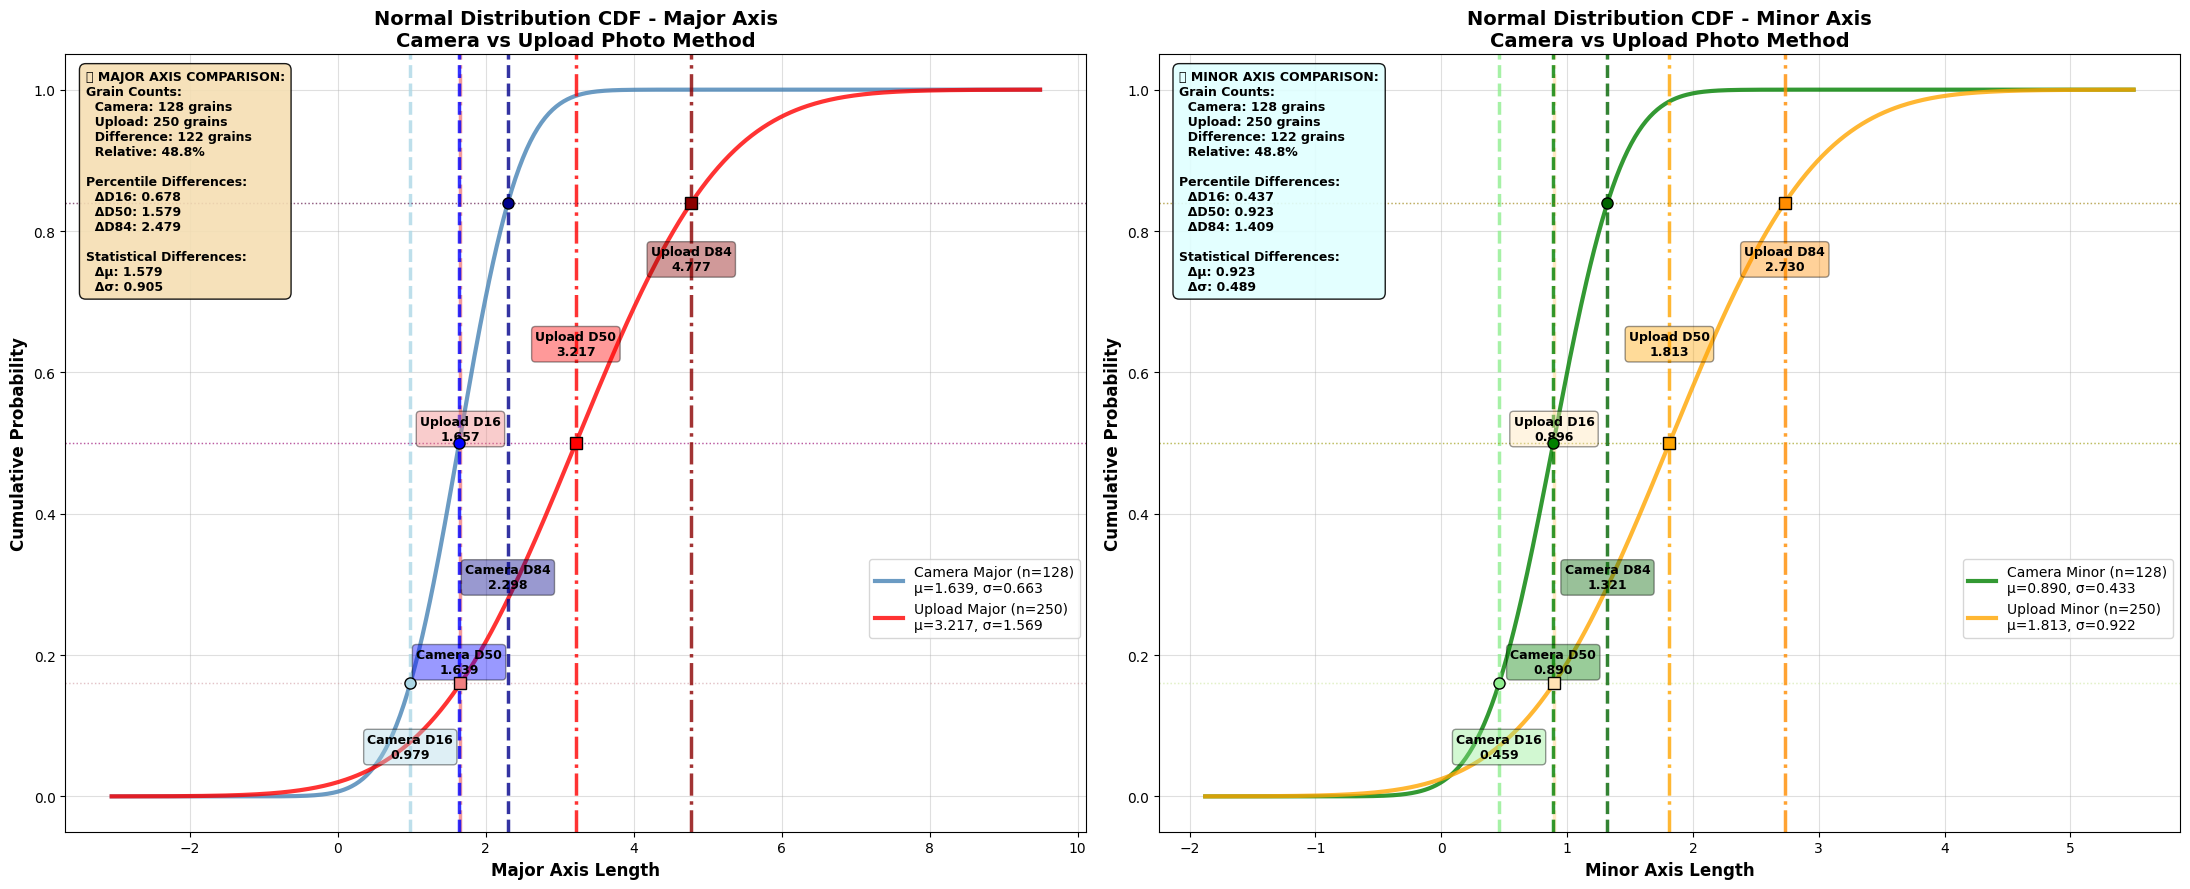

📊 COMPREHENSIVE GRAIN ANALYSIS COMPARISON
Analysis Date: 2025-08-07 18:05:22 UTC
User: esemsc-mcu24

MAJOR AXIS DETAILED COMPARISON:
--------------------------------------------------
Metric               Camera       Upload       Difference   Rel.Diff% 
--------------------------------------------------
Grain Count          128          250          122          48.8      
Mean                 1.639        3.217        1.579        96.4      
Std Dev              0.663        1.569        0.905        136.5     
D16                  0.979        1.657        0.678        69.3      
D50                  1.639        3.217        1.579        96.4      
D84                  2.298        4.777        2.479        107.9     

MINOR AXIS DETAILED COMPARISON:
--------------------------------------------------
Metric               Camera       Upload       Difference   Rel.Diff% 
--------------------------------------------------
Grain Count          128          250          122          48

In [ ]:
# Create enhanced normal distribution CDF comparison plot with grain counts and differences
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# Plot 1: Major Axis Normal CDFs with comprehensive annotations
if stats_summary['Camera Major'] and stats_summary['Upload Major']:
    # Get parameters and data
    camera_major_mean = stats_summary['Camera Major']['mean']
    camera_major_std = stats_summary['Camera Major']['std']
    upload_major_mean = stats_summary['Upload Major']['mean']
    upload_major_std = stats_summary['Upload Major']['std']

    # Get grain counts
    camera_major_count = len(stats_summary['Camera Major']['data'])
    upload_major_count = len(stats_summary['Upload Major']['data'])
    count_diff_major = abs(camera_major_count - upload_major_count)

    # Calculate theoretical D16, D50, D84 values
    camera_D16_major = norm.ppf(0.16, loc=camera_major_mean, scale=camera_major_std)
    camera_D50_major = norm.ppf(0.50, loc=camera_major_mean, scale=camera_major_std)
    camera_D84_major = norm.ppf(0.84, loc=camera_major_mean, scale=camera_major_std)

    upload_D16_major = norm.ppf(0.16, loc=upload_major_mean, scale=upload_major_std)
    upload_D50_major = norm.ppf(0.50, loc=upload_major_mean, scale=upload_major_std)
    upload_D84_major = norm.ppf(0.84, loc=upload_major_mean, scale=upload_major_std)

    # Create x range for plotting
    x_min = min(camera_major_mean - 4*camera_major_std, upload_major_mean - 4*upload_major_std)
    x_max = max(camera_major_mean + 4*camera_major_std, upload_major_mean + 4*upload_major_std)
    x_major = np.linspace(x_min, x_max, 500)

    # Calculate normal CDFs
    camera_major_cdf = norm.cdf(x_major, loc=camera_major_mean, scale=camera_major_std)
    upload_major_cdf = norm.cdf(x_major, loc=upload_major_mean, scale=upload_major_std)

    # Plot normal CDFs with grain count in labels
    ax1.plot(x_major, camera_major_cdf, linewidth=3, color='steelblue',
             label=f'Camera Major (n={camera_major_count})\nμ={camera_major_mean:.3f}, σ={camera_major_std:.3f}', alpha=0.8)
    ax1.plot(x_major, upload_major_cdf, linewidth=3, color='red',
             label=f'Upload Major (n={upload_major_count})\nμ={upload_major_mean:.3f}, σ={upload_major_std:.3f}', alpha=0.8)

    # Add D16, D50, D84 lines and annotations
    percentiles = [16, 50, 84]
    camera_values = [camera_D16_major, camera_D50_major, camera_D84_major]
    upload_values = [upload_D16_major, upload_D50_major, upload_D84_major]
    labels = ['D16', 'D50', 'D84']
    colors_camera = ['lightblue', 'blue', 'darkblue']
    colors_upload = ['lightcoral', 'red', 'darkred']

    for i, (p, cam_val, up_val, label, cam_color, up_color) in enumerate(
        zip(percentiles, camera_values, upload_values, labels, colors_camera, colors_upload)):

        # Camera percentile lines
        ax1.axvline(cam_val, color=cam_color, linestyle='--', linewidth=2.5, alpha=0.8)
        ax1.axhline(p/100, color=cam_color, linestyle=':', linewidth=1, alpha=0.4)
        ax1.plot(cam_val, p/100, 'o', color=cam_color, markersize=8,
                markeredgecolor='black', markeredgewidth=1, zorder=10)

        # Upload percentile lines
        ax1.axvline(up_val, color=up_color, linestyle='-.', linewidth=2.5, alpha=0.8)
        ax1.axhline(p/100, color=up_color, linestyle=':', linewidth=1, alpha=0.4)
        ax1.plot(up_val, p/100, 's', color=up_color, markersize=8,
                markeredgecolor='black', markeredgewidth=1, zorder=10)

        # Camera annotations
        y_pos_cam = 0.05 + i*0.12
        ax1.text(cam_val, y_pos_cam, f'Camera {label}\n{cam_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=cam_color, alpha=0.4),
                rotation=0)

        # Upload annotations
        y_pos_up = 0.50 + i*0.12
        ax1.text(up_val, y_pos_up, f'Upload {label}\n{up_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=up_color, alpha=0.4),
                rotation=0)

    # Add comprehensive statistics box
    stats_text = (f'📊 MAJOR AXIS COMPARISON:\n'
                 f'Grain Counts:\n'
                 f'  Camera: {camera_major_count} grains\n'
                 f'  Upload: {upload_major_count} grains\n'
                 f'  Difference: {count_diff_major} grains\n'
                 f'  Relative: {count_diff_major/max(camera_major_count, upload_major_count)*100:.1f}%\n\n'
                 f'Percentile Differences:\n'
                 f'  ΔD16: {abs(camera_D16_major - upload_D16_major):.3f}\n'
                 f'  ΔD50: {abs(camera_D50_major - upload_D50_major):.3f}\n'
                 f'  ΔD84: {abs(camera_D84_major - upload_D84_major):.3f}\n\n'
                 f'Statistical Differences:\n'
                 f'  Δμ: {abs(camera_major_mean - upload_major_mean):.3f}\n'
                 f'  Δσ: {abs(camera_major_std - upload_major_std):.3f}')

    ax1.text(0.02, 0.98, stats_text,
             transform=ax1.transAxes, fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.9),
             verticalalignment='top')

ax1.set_xlabel('Major Axis Length', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax1.set_title('Normal Distribution CDF - Major Axis\nCamera vs Upload Photo Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.4)
ax1.legend(loc='center right', bbox_to_anchor=(1.0, 0.3))

# Plot 2: Minor Axis Normal CDFs with comprehensive annotations
if stats_summary['Camera Minor'] and stats_summary['Upload Minor']:
    # Get parameters and data
    camera_minor_mean = stats_summary['Camera Minor']['mean']
    camera_minor_std = stats_summary['Camera Minor']['std']
    upload_minor_mean = stats_summary['Upload Minor']['mean']
    upload_minor_std = stats_summary['Upload Minor']['std']

    # Get grain counts
    camera_minor_count = len(stats_summary['Camera Minor']['data'])
    upload_minor_count = len(stats_summary['Upload Minor']['data'])
    count_diff_minor = abs(camera_minor_count - upload_minor_count)

    # Calculate theoretical D16, D50, D84 values
    camera_D16_minor = norm.ppf(0.16, loc=camera_minor_mean, scale=camera_minor_std)
    camera_D50_minor = norm.ppf(0.50, loc=camera_minor_mean, scale=camera_minor_std)
    camera_D84_minor = norm.ppf(0.84, loc=camera_minor_mean, scale=camera_minor_std)

    upload_D16_minor = norm.ppf(0.16, loc=upload_minor_mean, scale=upload_minor_std)
    upload_D50_minor = norm.ppf(0.50, loc=upload_minor_mean, scale=upload_minor_std)
    upload_D84_minor = norm.ppf(0.84, loc=upload_minor_mean, scale=upload_minor_std)

    # Create x range for plotting
    x_min = min(camera_minor_mean - 4*camera_minor_std, upload_minor_mean - 4*upload_minor_std)
    x_max = max(camera_minor_mean + 4*camera_minor_std, upload_minor_mean + 4*upload_minor_std)
    x_minor = np.linspace(x_min, x_max, 500)

    # Calculate normal CDFs
    camera_minor_cdf = norm.cdf(x_minor, loc=camera_minor_mean, scale=camera_minor_std)
    upload_minor_cdf = norm.cdf(x_minor, loc=upload_minor_mean, scale=upload_minor_std)

    # Plot normal CDFs with grain count in labels
    ax2.plot(x_minor, camera_minor_cdf, linewidth=3, color='green',
             label=f'Camera Minor (n={camera_minor_count})\nμ={camera_minor_mean:.3f}, σ={camera_minor_std:.3f}', alpha=0.8)
    ax2.plot(x_minor, upload_minor_cdf, linewidth=3, color='orange',
             label=f'Upload Minor (n={upload_minor_count})\nμ={upload_minor_mean:.3f}, σ={upload_minor_std:.3f}', alpha=0.8)

    # Add D16, D50, D84 lines and annotations for Minor axis
    camera_values_minor = [camera_D16_minor, camera_D50_minor, camera_D84_minor]
    upload_values_minor = [upload_D16_minor, upload_D50_minor, upload_D84_minor]
    colors_camera_minor = ['lightgreen', 'green', 'darkgreen']
    colors_upload_minor = ['moccasin', 'orange', 'darkorange']

    for i, (p, cam_val, up_val, label, cam_color, up_color) in enumerate(
        zip(percentiles, camera_values_minor, upload_values_minor, labels,
            colors_camera_minor, colors_upload_minor)):

        # Camera percentile lines
        ax2.axvline(cam_val, color=cam_color, linestyle='--', linewidth=2.5, alpha=0.8)
        ax2.axhline(p/100, color=cam_color, linestyle=':', linewidth=1, alpha=0.4)
        ax2.plot(cam_val, p/100, 'o', color=cam_color, markersize=8,
                markeredgecolor='black', markeredgewidth=1, zorder=10)

        # Upload percentile lines
        ax2.axvline(up_val, color=up_color, linestyle='-.', linewidth=2.5, alpha=0.8)
        ax2.axhline(p/100, color=up_color, linestyle=':', linewidth=1, alpha=0.4)
        ax2.plot(up_val, p/100, 's', color=up_color, markersize=8,
                markeredgecolor='black', markeredgewidth=1, zorder=10)

        # Camera annotations
        y_pos_cam = 0.05 + i*0.12
        ax2.text(cam_val, y_pos_cam, f'Camera {label}\n{cam_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=cam_color, alpha=0.4),
                rotation=0)

        # Upload annotations
        y_pos_up = 0.50 + i*0.12
        ax2.text(up_val, y_pos_up, f'Upload {label}\n{up_val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=up_color, alpha=0.4),
                rotation=0)

    # Add comprehensive statistics box for minor axis
    stats_text_minor = (f'📊 MINOR AXIS COMPARISON:\n'
                       f'Grain Counts:\n'
                       f'  Camera: {camera_minor_count} grains\n'
                       f'  Upload: {upload_minor_count} grains\n'
                       f'  Difference: {count_diff_minor} grains\n'
                       f'  Relative: {count_diff_minor/max(camera_minor_count, upload_minor_count)*100:.1f}%\n\n'
                       f'Percentile Differences:\n'
                       f'  ΔD16: {abs(camera_D16_minor - upload_D16_minor):.3f}\n'
                       f'  ΔD50: {abs(camera_D50_minor - upload_D50_minor):.3f}\n'
                       f'  ΔD84: {abs(camera_D84_minor - upload_D84_minor):.3f}\n\n'
                       f'Statistical Differences:\n'
                       f'  Δμ: {abs(camera_minor_mean - upload_minor_mean):.3f}\n'
                       f'  Δσ: {abs(camera_minor_std - upload_minor_std):.3f}')

    ax2.text(0.02, 0.98, stats_text_minor,
             transform=ax2.transAxes, fontsize=9, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', alpha=0.9),
             verticalalignment='top')

ax2.set_xlabel('Minor Axis Length', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax2.set_title('Normal Distribution CDF - Minor Axis\nCamera vs Upload Photo Method', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.4)
ax2.legend(loc='center right', bbox_to_anchor=(1.0, 0.3))

plt.tight_layout()
plt.show()

# Print comprehensive comparison table
print("📊 COMPREHENSIVE GRAIN ANALYSIS COMPARISON")
print("="*80)
print(f"Analysis Date: 2025-08-07 18:05:22 UTC")
print(f"User: esemsc-mcu24")
print("="*80)

if stats_summary['Camera Major'] and stats_summary['Upload Major']:
    print(f"\nMAJOR AXIS DETAILED COMPARISON:")
    print("-"*50)
    print(f"{'Metric':<20} {'Camera':<12} {'Upload':<12} {'Difference':<12} {'Rel.Diff%':<10}")
    print("-"*50)

    # Grain counts
    cam_count = len(stats_summary['Camera Major']['data'])
    up_count = len(stats_summary['Upload Major']['data'])
    count_diff = abs(cam_count - up_count)
    rel_count_diff = count_diff / max(cam_count, up_count) * 100
    print(f"{'Grain Count':<20} {cam_count:<12} {up_count:<12} {count_diff:<12} {rel_count_diff:<10.1f}")

    # Statistics
    cam_mean = stats_summary['Camera Major']['mean']
    up_mean = stats_summary['Upload Major']['mean']
    mean_diff = abs(cam_mean - up_mean)
    rel_mean_diff = mean_diff / cam_mean * 100
    print(f"{'Mean':<20} {cam_mean:<12.3f} {up_mean:<12.3f} {mean_diff:<12.3f} {rel_mean_diff:<10.1f}")

    cam_std = stats_summary['Camera Major']['std']
    up_std = stats_summary['Upload Major']['std']
    std_diff = abs(cam_std - up_std)
    rel_std_diff = std_diff / cam_std * 100
    print(f"{'Std Dev':<20} {cam_std:<12.3f} {up_std:<12.3f} {std_diff:<12.3f} {rel_std_diff:<10.1f}")

    # Percentiles
    for perc, label in [(16, 'D16'), (50, 'D50'), (84, 'D84')]:
        cam_val = norm.ppf(perc/100, loc=cam_mean, scale=cam_std)
        up_val = norm.ppf(perc/100, loc=up_mean, scale=up_std)
        diff_val = abs(cam_val - up_val)
        rel_diff_val = diff_val / cam_val * 100
        print(f"{label:<20} {cam_val:<12.3f} {up_val:<12.3f} {diff_val:<12.3f} {rel_diff_val:<10.1f}")

if stats_summary['Camera Minor'] and stats_summary['Upload Minor']:
    print(f"\nMINOR AXIS DETAILED COMPARISON:")
    print("-"*50)
    print(f"{'Metric':<20} {'Camera':<12} {'Upload':<12} {'Difference':<12} {'Rel.Diff%':<10}")
    print("-"*50)

    # Grain counts
    cam_count = len(stats_summary['Camera Minor']['data'])
    up_count = len(stats_summary['Upload Minor']['data'])
    count_diff = abs(cam_count - up_count)
    rel_count_diff = count_diff / max(cam_count, up_count) * 100
    print(f"{'Grain Count':<20} {cam_count:<12} {up_count:<12} {count_diff:<12} {rel_count_diff:<10.1f}")

    # Statistics
    cam_mean = stats_summary['Camera Minor']['mean']
    up_mean = stats_summary['Upload Minor']['mean']
    mean_diff = abs(cam_mean - up_mean)
    rel_mean_diff = mean_diff / cam_mean * 100
    print(f"{'Mean':<20} {cam_mean:<12.3f} {up_mean:<12.3f} {mean_diff:<12.3f} {rel_mean_diff:<10.1f}")

    cam_std = stats_summary['Camera Minor']['std']
    up_std = stats_summary['Upload Minor']['std']
    std_diff = abs(cam_std - up_std)
    rel_std_diff = std_diff / cam_std * 100
    print(f"{'Std Dev':<20} {cam_std:<12.3f} {up_std:<12.3f} {std_diff:<12.3f} {rel_std_diff:<10.1f}")

    # Percentiles
    for perc, label in [(16, 'D16'), (50, 'D50'), (84, 'D84')]:
        cam_val = norm.ppf(perc/100, loc=cam_mean, scale=cam_std)
        up_val = norm.ppf(perc/100, loc=up_mean, scale=up_std)
        diff_val = abs(cam_val - up_val)
        rel_diff_val = diff_val / cam_val * 100
        print(f"{label:<20} {cam_val:<12.3f} {up_val:<12.3f} {diff_val:<12.3f} {rel_diff_val:<10.1f}")

print(f"\n✅ Analysis completed successfully!")
print(f"📧 Results generated for user: esemsc-mcu24")

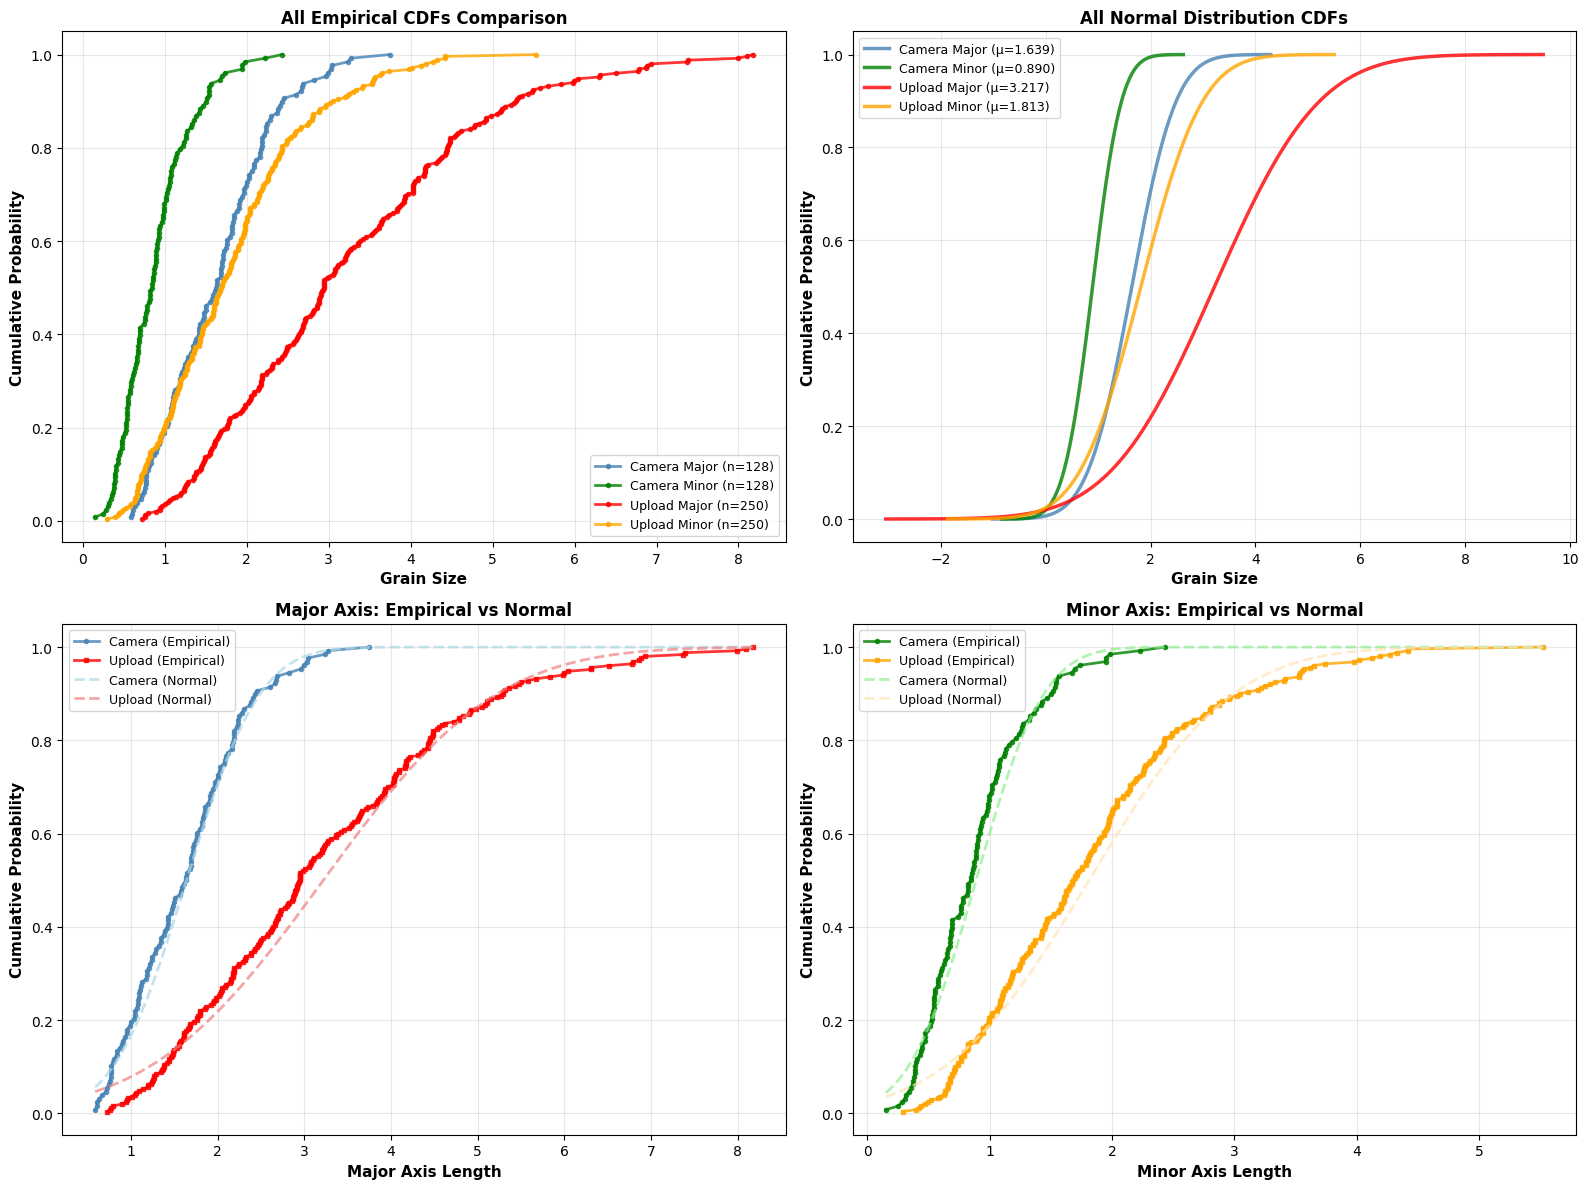

In [ ]:
# Create a comprehensive 4-in-1 comparison plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Color scheme
colors = {
    'Camera Major': 'steelblue',
    'Upload Major': 'red',
    'Camera Minor': 'green',
    'Upload Minor': 'orange'
}

# Plot 1: All Empirical CDFs
for name, data in datasets.items():
    if len(data) > 0:
        sorted_data = np.sort(data)
        cdf_data = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax1.plot(sorted_data, cdf_data, 'o-', linewidth=2, markersize=3,
                color=colors[name], label=f'{name} (n={len(data)})', alpha=0.8)

ax1.set_xlabel('Grain Size', fontsize=11, fontweight='bold')
ax1.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax1.set_title('All Empirical CDFs Comparison', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Plot 2: All Normal CDFs
for name, stats in stats_summary.items():
    if stats:
        mean_val, std_val = stats['mean'], stats['std']
        x_range = np.linspace(mean_val - 4*std_val, mean_val + 4*std_val, 300)
        normal_cdf = norm.cdf(x_range, loc=mean_val, scale=std_val)
        ax2.plot(x_range, normal_cdf, linewidth=2.5, color=colors[name],
                label=f'{name} (μ={mean_val:.3f})', alpha=0.8)

ax2.set_xlabel('Grain Size', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax2.set_title('All Normal Distribution CDFs', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# Plot 3: Major Axis Detailed Comparison
if len(camera_major) > 0 and len(upload_major) > 0:
    # Empirical
    sorted_camera_major = np.sort(camera_major)
    cdf_camera_major = np.arange(1, len(sorted_camera_major) + 1) / len(sorted_camera_major)
    ax3.plot(sorted_camera_major, cdf_camera_major, 'o-', linewidth=2, markersize=3,
             color='steelblue', label='Camera (Empirical)', alpha=0.8)

    sorted_upload_major = np.sort(upload_major)
    cdf_upload_major = np.arange(1, len(sorted_upload_major) + 1) / len(sorted_upload_major)
    ax3.plot(sorted_upload_major, cdf_upload_major, 's-', linewidth=2, markersize=3,
             color='red', label='Upload (Empirical)', alpha=0.8)

    # Normal fits
    if stats_summary['Camera Major'] and stats_summary['Upload Major']:
        x_range = np.linspace(min(camera_major.min(), upload_major.min()),
                             max(camera_major.max(), upload_major.max()), 200)

        camera_normal = norm.cdf(x_range, loc=stats_summary['Camera Major']['mean'],
                               scale=stats_summary['Camera Major']['std'])
        upload_normal = norm.cdf(x_range, loc=stats_summary['Upload Major']['mean'],
                               scale=stats_summary['Upload Major']['std'])

        ax3.plot(x_range, camera_normal, '--', linewidth=2, color='lightblue',
                label='Camera (Normal)', alpha=0.7)
        ax3.plot(x_range, upload_normal, '--', linewidth=2, color='lightcoral',
                label='Upload (Normal)', alpha=0.7)

ax3.set_xlabel('Major Axis Length', fontsize=11, fontweight='bold')
ax3.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax3.set_title('Major Axis: Empirical vs Normal', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

# Plot 4: Minor Axis Detailed Comparison
if len(camera_minor) > 0 and len(upload_minor) > 0:
    # Empirical
    sorted_camera_minor = np.sort(camera_minor)
    cdf_camera_minor = np.arange(1, len(sorted_camera_minor) + 1) / len(sorted_camera_minor)
    ax4.plot(sorted_camera_minor, cdf_camera_minor, 'o-', linewidth=2, markersize=3,
             color='green', label='Camera (Empirical)', alpha=0.8)

    sorted_upload_minor = np.sort(upload_minor)
    cdf_upload_minor = np.arange(1, len(sorted_upload_minor) + 1) / len(sorted_upload_minor)
    ax4.plot(sorted_upload_minor, cdf_upload_minor, 's-', linewidth=2, markersize=3,
             color='orange', label='Upload (Empirical)', alpha=0.8)

    # Normal fits
    if stats_summary['Camera Minor'] and stats_summary['Upload Minor']:
        x_range = np.linspace(min(camera_minor.min(), upload_minor.min()),
                             max(camera_minor.max(), upload_minor.max()), 200)

        camera_normal = norm.cdf(x_range, loc=stats_summary['Camera Minor']['mean'],
                               scale=stats_summary['Camera Minor']['std'])
        upload_normal = norm.cdf(x_range, loc=stats_summary['Upload Minor']['mean'],
                               scale=stats_summary['Upload Minor']['std'])

        ax4.plot(x_range, camera_normal, '--', linewidth=2, color='lightgreen',
                label='Camera (Normal)', alpha=0.7)
        ax4.plot(x_range, upload_normal, '--', linewidth=2, color='moccasin',
                label='Upload (Normal)', alpha=0.7)

ax4.set_xlabel('Minor Axis Length', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=11, fontweight='bold')
ax4.set_title('Minor Axis: Empirical vs Normal', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()